DataFrame columns after cleaning:
Index(['circle', 'monument', 'domestic_2019', 'foreign_2019', 'domestic_2020',
       'foreign_2020', '%_growth_2021-21/2019-20-domestic',
       '%_growth_2021-21/2019-20-foreign', 'total_visitors_2019',
       'total_visitors_2020', 'total_visitors', 'crowd_index', 'crowd_level'],
      dtype='object')
── Class Distribution ──────────────────────────
Crowd_Level
High      49
Low       48
Medium    48
Name: count, dtype: int64

Thresholds → Low ≤ 62,297 | Medium ≤ 241,697 | High > 241,697

Train size: 116 | Test size: 29

── Model Evaluation ────────────────────────────
Test Accuracy : 72.41%

Classification Report:
              precision    recall  f1-score   support

        High       0.80      0.80      0.80        10
         Low       0.78      0.70      0.74        10
      Medium       0.60      0.67      0.63         9

    accuracy                           0.72        29
   macro avg       0.73      0.72      0.72        29
weighted avg   

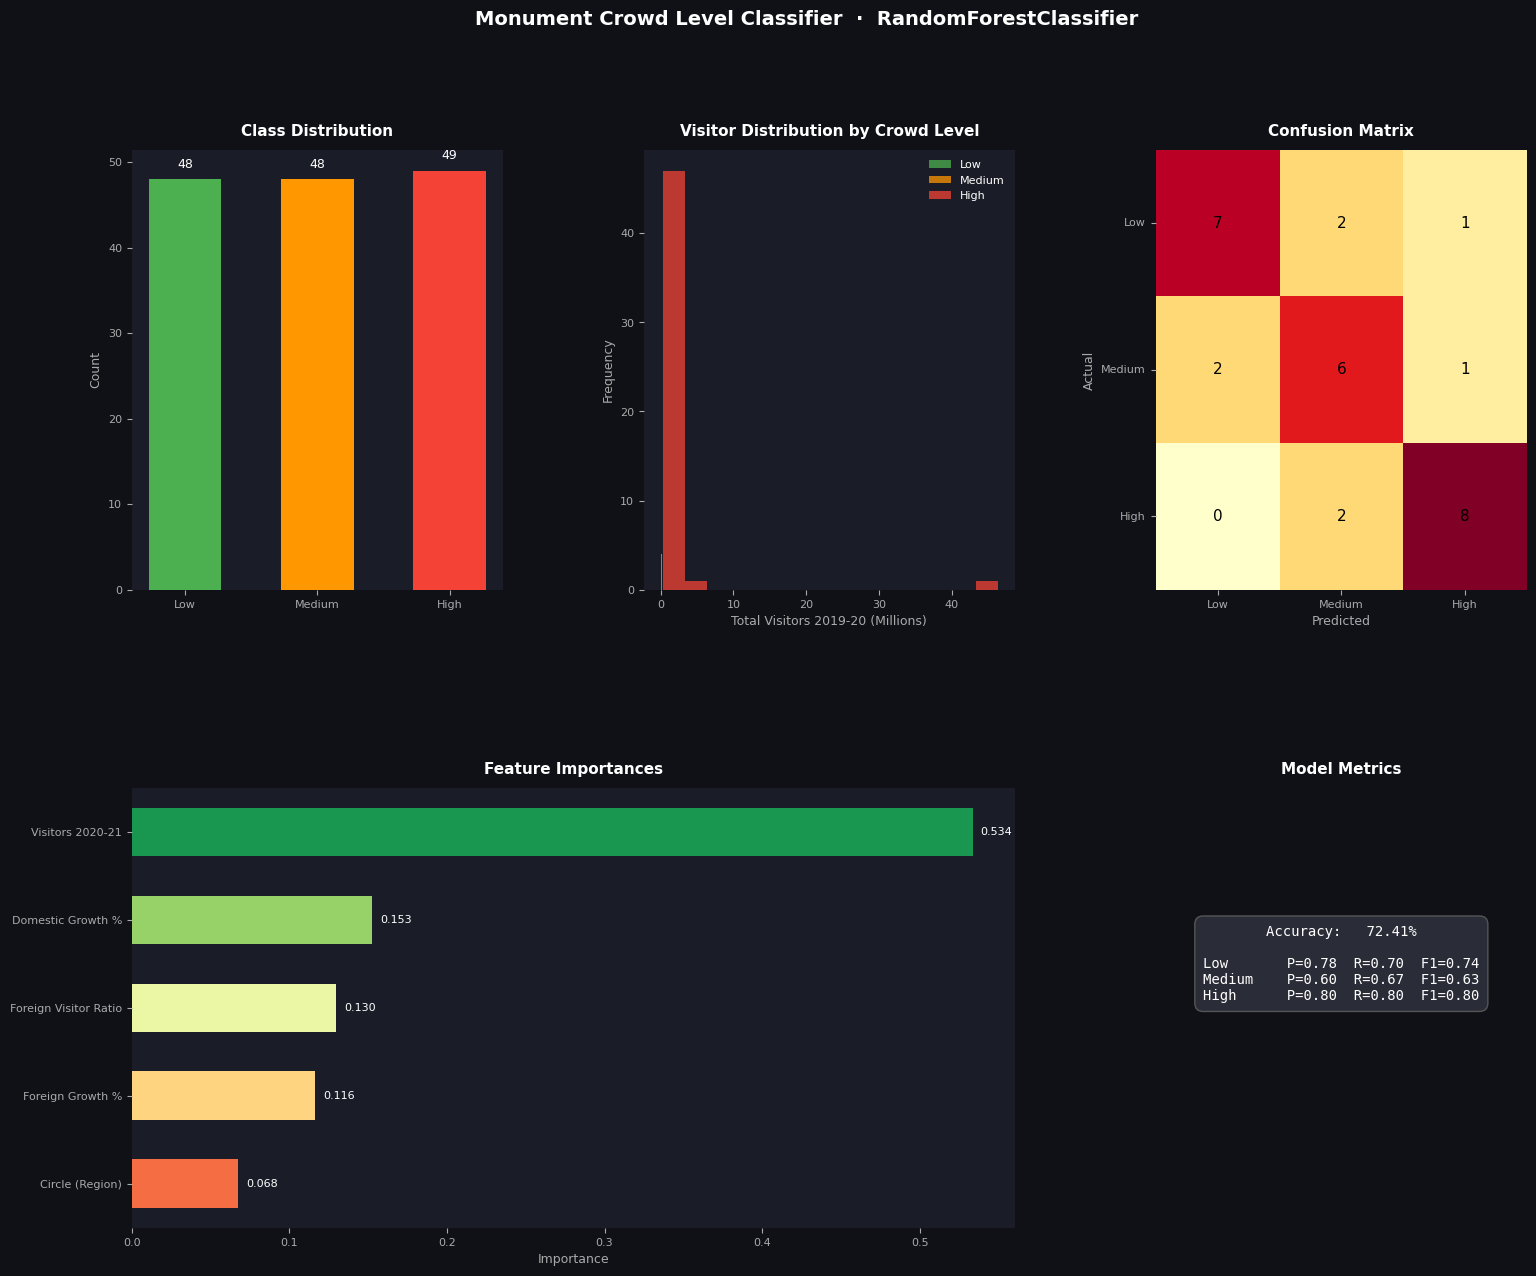


Plot saved as monument_classifier_results.png
         Circle                                                                                                       Monument  Total Visitors (2019-20) Actual Level Predicted Level  Match
    Grand Total                                                                                                    Grand Total                  46363636         High            High   True
           Agra                                                                                                      Taj Mahal                   5075125         High            High   True
          Delhi                                                                                                    Qutub Minar                   2303464         High            High   True
          Delhi                                                                                                       Red Fort                   2291408         High            High   True
        

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder


# ── 1. Load & Clean ──────────────────────────────────────────────────────────

df = pd.read_csv("India-Tourism-Statistics-2021-Table-5.2.3.csv")

# Drop subtotal rows
df = df[df["circle"] != "Total"].copy()
df.columns = df.columns.str.strip()
df["monument"] = df["monument"].str.strip()

print("DataFrame columns after cleaning:")
print(df.columns)


# ── 2. Feature Engineering ───────────────────────────────────────────────────

df["Total_Visitors_2019"] = df["domestic_2019"] + df["foreign_2019"]
df["Total_Visitors_2021"] = df["domestic_2020"] + df["foreign_2020"]
df["Foreign_Ratio"]       = df["foreign_2019"] / (df["Total_Visitors_2019"] + 1)
df["Domestic_Growth"]     = df["%_growth_2021-21/2019-20-domestic"]
df["Foreign_Growth"]      = df["%_growth_2021-21/2019-20-foreign"]


# ── 3. Label Crowd Level ─────────────────────────────────────────────────────
# Thresholds based on 33rd and 66th percentile of 2019-20 total visitors

q33 = df["Total_Visitors_2019"].quantile(0.33)
q66 = df["Total_Visitors_2019"].quantile(0.66)

def assign_crowd_level(visitors):
    if visitors <= q33:
        return "Low"
    elif visitors <= q66:
        return "Medium"
    else:
        return "High"

df["Crowd_Level"] = df["Total_Visitors_2019"].apply(assign_crowd_level)

print("── Class Distribution ──────────────────────────")
print(df["Crowd_Level"].value_counts())
print(f"\nThresholds → Low ≤ {q33:,.0f} | Medium ≤ {q66:,.0f} | High > {q66:,.0f}\n")


# ── 4. Encode Categorical Feature ───────────────────────────────────────────

le = LabelEncoder()
df["Circle_Enc"] = le.fit_transform(df["circle"])


# ── 5. Prepare Features & Target ─────────────────────────────────────────────

FEATURES = [
    "Total_Visitors_2021",   # Post-COVID footfall
    "Foreign_Ratio",         # International appeal
    "Domestic_Growth",       # Domestic recovery trend
    "Foreign_Growth",      # Foreign recovery trend
    "Circle_Enc",            # ASI administrative region
]
TARGET = "Crowd_Level"

X = df[FEATURES]
y = df[TARGET]


# ── 6. Train / Test Split ────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Preserve class balance in both splits
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")


# ── 7. Train RandomForestClassifier ──────────────────────────────────────────

clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"   # Handles any minor class imbalance
)
clf.fit(X_train, y_train)


# ── 8. Evaluate ───────────────────────────────────────────────────────────────

y_pred = clf.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print("\n── Model Evaluation ────────────────────────────")
print(f"Test Accuracy : {acc:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ── 9. Visualise Results ──────────────────────────────────────────────────────

ORDER   = ["Low", "Medium", "High"]
PALETTE = {"Low": "#4CAF50", "Medium": "#FF9800", "High": "#F44336"}

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor("#0F1117")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

title_kw = dict(color="white", fontsize=11, fontweight="bold", pad=10)
label_kw = dict(color="#AAAAAA", fontsize=9)
tick_kw  = dict(colors="#AAAAAA", labelsize=8)

# (A) Class Distribution
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor("#1A1D27")
counts = df["Crowd_Level"].value_counts().reindex(ORDER)
bars = ax0.bar(ORDER, counts.values,
               color=[PALETTE[l] for l in ORDER],
               edgecolor="none", width=0.55)
for b in bars:
    ax0.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
             str(int(b.get_height())), ha="center", va="bottom",
             color="white", fontsize=9)
ax0.set_title("Class Distribution", **title_kw)
ax0.set_ylabel("Count", **label_kw)
ax0.tick_params(axis="x", **tick_kw)
ax0.tick_params(axis="y", **tick_kw)
ax0.spines[:].set_visible(False)

# (B) Visitor Distribution by Crowd Level
ax1 = fig.add_subplot(gs[0, 1])
ax1.set_facecolor("#1A1D27")
for lvl in ORDER:
    subset = df[df["Crowd_Level"] == lvl]["Total_Visitors_2019"] / 1e6
    ax1.hist(subset, bins=15, alpha=0.75, label=lvl,
             color=PALETTE[lvl], edgecolor="none")
ax1.set_title("Visitor Distribution by Crowd Level", **title_kw)
ax1.set_xlabel("Total Visitors 2019-20 (Millions)", **label_kw)
ax1.set_ylabel("Frequency", **label_kw)
ax1.tick_params(axis="x", **tick_kw)
ax1.tick_params(axis="y", **tick_kw)
ax1.legend(fontsize=8, facecolor="#1A1D27", labelcolor="white", edgecolor="none")
ax1.spines[:].set_visible(False)

# (C) Confusion Matrix
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor("#1A1D27")
cm = confusion_matrix(y_test, y_pred, labels=ORDER)
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=ORDER, yticklabels=ORDER,
            ax=ax2, cbar=False,
            annot_kws={"size": 11, "color": "black"})
ax2.set_title("Confusion Matrix", **title_kw)
ax2.set_xlabel("Predicted", **label_kw)
ax2.set_ylabel("Actual", **label_kw)
ax2.tick_params(axis="x", colors="#AAAAAA", labelsize=8)
ax2.tick_params(axis="y", colors="#AAAAAA", labelsize=8, rotation=0)

# (D) Feature Importances
ax3 = fig.add_subplot(gs[1, 0:2])
ax3.set_facecolor("#1A1D27")
feat_imp = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=True)
FEAT_LABELS = {
    "Total_Visitors_2021": "Visitors 2020-21",
    "Foreign_Ratio":       "Foreign Visitor Ratio",
    "Domestic_Growth":     "Domestic Growth %",
    "Foreign_Growth":      "Foreign Growth %",
    "Circle_Enc":          "Circle (Region)",
}
feat_imp.index = [FEAT_LABELS[f] for f in feat_imp.index]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))
bars2  = ax3.barh(feat_imp.index, feat_imp.values,
                  color=colors, edgecolor="none", height=0.55)
for b in bars2:
    ax3.text(b.get_width() + 0.005, b.get_y() + b.get_height()/2,
             f"{b.get_width():.3f}", va="center", color="white", fontsize=8)
ax3.set_title("Feature Importances", **title_kw)
ax3.set_xlabel("Importance", **label_kw)
ax3.tick_params(axis="x", **tick_kw)
ax3.tick_params(axis="y", **tick_kw)
ax3.spines[:].set_visible(False)

# (E) Metrics Summary Card
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor("#1A1D27")
ax4.axis("off")
report = classification_report(y_test, y_pred, output_dict=True)
metrics_text = (
    f"Accuracy:   {acc:.2%}\n\n"
    + "\n".join([
        f"{cls:<8}  P={report[cls]['precision']:.2f}  "
        f"R={report[cls]['recall']:.2f}  "
        f"F1={report[cls]['f1-score']:.2f}"
        for cls in ORDER
    ])
)
ax4.text(0.5, 0.6, metrics_text,
         ha="center", va="center", transform=ax4.transAxes,
         fontsize=10, color="white", fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.6", facecolor="#2A2D37", edgecolor="#555"))
ax4.set_title("Model Metrics", **title_kw)

fig.suptitle("Monument Crowd Level Classifier  ·  RandomForestClassifier",
             color="white", fontsize=14, fontweight="bold", y=0.98)

plt.savefig("monument_classifier_results.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("\nPlot saved as monument_classifier_results.png")


# ── 10. Predict on New Data ───────────────────────────────────────────────────
# Example: predict crowd level for a new/unseen monument
#
# new_monument = pd.DataFrame([{
#     "Total_Visitors_2021": 150000,
#     "Foreign_Ratio":       0.12,
#     "Domestic_Growth":     -45.0,
#     "Foreign_Growth":      -88.0,
#     "Circle_Enc":          3,          # use le.transform(["CircleName"])[0]
# }])
# prediction = clf.predict(new_monument)
# print("Predicted Crowd Level:", prediction[0])
df_model = df.copy()
df_model["Predicted_Crowd"] = clf.predict(X)   # predict on full dataset

results = df_model[["circle",  "monument",
                     "Total_Visitors_2019", "Crowd_Level",
                     "Predicted_Crowd"]].copy()

results.columns = ["Circle", "Monument", "Total Visitors (2019-20)",
                   "Actual Level", "Predicted Level"]

results["Match"] = results["Actual Level"] == results["Predicted Level"]
results = results.sort_values("Total Visitors (2019-20)", ascending=False)

print(results.to_string(index=False))

low_medium = results[
    ((results["Actual Level"] == "Low")    & (results["Predicted Level"] == "Low")) |
    ((results["Actual Level"] == "Medium") & (results["Predicted Level"] == "Medium"))
]

print(f"Total monuments correctly predicted as Low or Medium: {len(low_medium)}\n")
print(low_medium.to_string(index=False))